# 🤖 Customer Complaint Analyzer - AI Agent

**IBM SkillsBuild Winter Certification Program – Applied Artificial Intelligence**

---

## 📋 Project Overview

This AI agent automatically analyzes customer complaints to help businesses:
- 🎯 **Classify complaints** by category (Billing, Product, Service, Delivery, Technical)
- 😡 **Detect sentiment** (Angry, Frustrated, Neutral, Mild)
- ⚡ **Assign priority** levels (High, Medium, Low)
- 💬 **Generate resolution templates** for quick responses

### Business Value
- Automates complaint routing to appropriate departments
- Prioritizes urgent cases requiring immediate attention
- Reduces response time with template suggestions
- Provides insights into common customer issues

---

## 🔧 Step 1: Setup & Installation

Installing all required libraries for NLP and machine learning.

In [13]:
# Install required libraries
%pip install nltk textblob scikit-learn pandas matplotlib seaborn wordcloud ipywidgets -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Interactive widgets
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # ← ADD THIS
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('wordnet', quiet=True)

print("✅ All imports successful!")

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

✅ All imports successful!


## 📊 Step 2: Sample Complaint Dataset

Creating realistic customer complaint data for demonstration.

In [3]:
# Sample customer complaints dataset
complaints_data = [
    # BILLING ISSUES
    {"complaint": "I was charged twice for the same order! This is unacceptable. I want an immediate refund or I'm canceling my account.", "category": "Billing"},
    {"complaint": "Your billing system is terrible. I've been overcharged for three months straight. Fix this immediately!", "category": "Billing"},
    {"complaint": "I noticed an extra charge on my bill. Can you please look into this?", "category": "Billing"},
    {"complaint": "The invoice shows incorrect amounts. I need clarification on these charges.", "category": "Billing"},
    {"complaint": "Why am I being billed for services I cancelled last month? This is fraudulent!", "category": "Billing"},
    {"complaint": "Double charged again! Your payment system is broken. Demanding full refund ASAP!", "category": "Billing"},
    
    # PRODUCT QUALITY
    {"complaint": "The product I received is completely defective. It doesn't work at all! I want a replacement immediately.", "category": "Product"},
    {"complaint": "This is the worst quality product I've ever bought. It broke within 2 days. Absolutely disgusted!", "category": "Product"},
    {"complaint": "The item is not as described. It's smaller and cheaper quality than shown in pictures.", "category": "Product"},
    {"complaint": "Product arrived damaged. The packaging was poor. Need urgent replacement.", "category": "Product"},
    {"complaint": "I received the wrong color. Can I exchange it for the correct one?", "category": "Product"},
    {"complaint": "The product stopped working after one week. This is unacceptable for the price I paid!", "category": "Product"},
    {"complaint": "Terrible product quality! Material feels cheap and broke immediately. Want my money back!", "category": "Product"},
    
    # CUSTOMER SERVICE
    {"complaint": "Your customer service is horrible! I've been on hold for 2 hours and no one has helped me.", "category": "Service"},
    {"complaint": "The representative was extremely rude and unhelpful. This is the worst service I've experienced.", "category": "Service"},
    {"complaint": "I've called 5 times about the same issue and still no resolution. Absolutely frustrated!", "category": "Service"},
    {"complaint": "Customer support agent hung up on me. This is completely unprofessional!", "category": "Service"},
    {"complaint": "No one is responding to my emails. I've been waiting for a week for a simple answer.", "category": "Service"},
    {"complaint": "The staff was not very knowledgeable about the product. I expected better service.", "category": "Service"},
    
    # DELIVERY ISSUES
    {"complaint": "My order is 2 weeks late! This is unacceptable. I need it urgently for a gift.", "category": "Delivery"},
    {"complaint": "Package never arrived and tracking shows it's lost. Need immediate replacement!", "category": "Delivery"},
    {"complaint": "Delivery person left package in the rain. Everything is ruined. Demanding refund!", "category": "Delivery"},
    {"complaint": "Wrong address delivery. I still haven't received my order after 10 days.", "category": "Delivery"},
    {"complaint": "The estimated delivery time was not met. Can you provide an update?", "category": "Delivery"},
    {"complaint": "Shipment was delayed by a week with no notification. Very disappointed.", "category": "Delivery"},
    
    # TECHNICAL SUPPORT
    {"complaint": "The app keeps crashing every time I try to login. This is extremely frustrating!", "category": "Technical"},
    {"complaint": "Your website is full of bugs. Can't complete my purchase. Fix your tech!", "category": "Technical"},
    {"complaint": "I can't access my account. The password reset link doesn't work. Need immediate help!", "category": "Technical"},
    {"complaint": "Technical issues with payment gateway. Transaction failed multiple times.", "category": "Technical"},
    {"complaint": "The mobile app is not compatible with my device. Can you help?", "category": "Technical"},
    {"complaint": "Error messages keep popping up. The system is unusable right now!", "category": "Technical"},
    {"complaint": "Your platform is so slow it's unusable. Tried on multiple browsers. All terrible!", "category": "Technical"},
    
    # MIXED ADDITIONAL COMPLAINTS
    {"complaint": "I'm extremely angry! Three issues: wrong product, late delivery, and rude service. Cancel everything!", "category": "Service"},
    {"complaint": "Subscription keeps renewing even though I cancelled it. This feels like a scam!", "category": "Billing"},
    {"complaint": "The return process is too complicated. Just want to send this defective item back.", "category": "Product"},
    {"complaint": "Still waiting for customer service to call me back as promised yesterday.", "category": "Service"},
    {"complaint": "Tracking information hasn't updated in 5 days. Where is my package?", "category": "Delivery"},
    {"complaint": "Cannot download the invoice. Your website has technical problems.", "category": "Technical"},
    {"complaint": "Received partial order. Half the items are missing. Need the rest shipped ASAP!", "category": "Delivery"},
    {"complaint": "The quality has gone downhill. I've been a loyal customer for years and this is disappointing.", "category": "Product"},
]

# Create DataFrame
df = pd.DataFrame(complaints_data)
df['complaint_id'] = ['CMP' + str(i+1001) for i in range(len(df))]
df['customer_name'] = [f'Customer_{i+1}' for i in range(len(df))]

# Reorder columns
df = df[['complaint_id', 'customer_name', 'complaint', 'category']]

print(f"✅ Created dataset with {len(df)} customer complaints")
print(f"\n📊 Category distribution:")
print(df['category'].value_counts())
print("\n" + "="*80)
print("Sample complaints:")
print("="*80)
df.head(10)

✅ Created dataset with 40 customer complaints

📊 Category distribution:
category
Product      9
Delivery     8
Service      8
Technical    8
Billing      7
Name: count, dtype: int64

Sample complaints:


,complaint_id,customer_name,complaint,category
0,CMP1001,Customer_1,I was charged twice for the same order! This i...,Billing
1,CMP1002,Customer_2,Your billing system is terrible. I've been ove...,Billing
2,CMP1003,Customer_3,I noticed an extra charge on my bill. Can you ...,Billing
3,CMP1004,Customer_4,The invoice shows incorrect amounts. I need cl...,Billing
4,CMP1005,Customer_5,Why am I being billed for services I cancelled...,Billing
5,CMP1006,Customer_6,Double charged again! Your payment system is b...,Billing
6,CMP1007,Customer_7,The product I received is completely defective...,Product
7,CMP1008,Customer_8,This is the worst quality product I've ever bo...,Product
8,CMP1009,Customer_9,The item is not as described. It's smaller and...,Product
9,CMP1010,Customer_10,Product arrived damaged. The packaging was poo...,Product


## 🧹 Step 3: Text Preprocessing

Clean and prepare text data for analysis.

In [4]:
class TextPreprocessor:
    """Handles text cleaning and preprocessing"""
    
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        # Keep some important words for sentiment
        self.stop_words -= {'not', 'no', 'never', 'neither', 'nor', 'cannot', 'shouldn\'t', 'wouldn\'t'}
    
    def clean_text(self, text):
        """Basic text cleaning"""
        # Convert to lowercase
        text = text.lower()
        # Remove special characters but keep apostrophes
        text = re.sub(r'[^a-zA-Z\s\']', ' ', text)
        # Remove extra whitespace
        text = ' '.join(text.split())
        return text
    
    def tokenize(self, text):
        """Tokenize text"""
        return word_tokenize(text)
    
    def remove_stopwords(self, tokens):
        """Remove stopwords but keep negations"""
        return [word for word in tokens if word not in self.stop_words]
    
    def preprocess(self, text, remove_stops=True):
        """Complete preprocessing pipeline"""
        cleaned = self.clean_text(text)
        tokens = self.tokenize(cleaned)
        if remove_stops:
            tokens = self.remove_stopwords(tokens)
        return ' '.join(tokens)

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Add preprocessed column
df['complaint_processed'] = df['complaint'].apply(lambda x: preprocessor.preprocess(x, remove_stops=False))

print("✅ Text preprocessing complete!")
print("\nExample:")
print(f"Original: {df['complaint'].iloc[0]}")
print(f"Processed: {df['complaint_processed'].iloc[0]}")

✅ Text preprocessing complete!

Example:
Original: I was charged twice for the same order! This is unacceptable. I want an immediate refund or I'm canceling my account.
Processed: i was charged twice for the same order this is unacceptable i want an immediate refund or i 'm canceling my account


## 😡 Step 4: Sentiment Analysis Engine

Detect sentiment and emotional intensity of complaints.

In [5]:
class SentimentAnalyzer:
    """Analyzes sentiment using VADER and TextBlob"""
    
    def __init__(self):
        self.vader = SentimentIntensityAnalyzer()
    
    def analyze_vader(self, text):
        """Get VADER sentiment scores"""
        scores = self.vader.polarity_scores(text)
        return scores
    
    def analyze_textblob(self, text):
        """Get TextBlob sentiment"""
        blob = TextBlob(text)
        return blob.sentiment.polarity
    
    def classify_sentiment(self, compound_score):
        """Classify sentiment into categories"""
        if compound_score <= -0.6:
            return "😡 ANGRY"
        elif compound_score <= -0.2:
            return "😤 FRUSTRATED"
        elif compound_score <= 0.2:
            return "😐 NEUTRAL"
        else:
            return "🙂 MILD"
    
    def get_sentiment_color(self, sentiment):
        """Get color for visualization"""
        colors = {
            "😡 ANGRY": "#d32f2f",
            "😤 FRUSTRATED": "#f57c00",
            "😐 NEUTRAL": "#795548",
            "🙂 MILD": "#388e3c"
        }
        return colors.get(sentiment, "#888888")
    
    def analyze(self, text):
        """Complete sentiment analysis"""
        vader_scores = self.analyze_vader(text)
        textblob_score = self.analyze_textblob(text)
        
        # Use VADER compound score for classification
        sentiment = self.classify_sentiment(vader_scores['compound'])
        
        return {
            'sentiment': sentiment,
            'compound': vader_scores['compound'],
            'positive': vader_scores['pos'],
            'negative': vader_scores['neg'],
            'neutral': vader_scores['neu'],
            'textblob': textblob_score
        }

# Initialize sentiment analyzer
sentiment_analyzer = SentimentAnalyzer()

# Analyze all complaints
print("Analyzing sentiment for all complaints...")
sentiment_results = df['complaint'].apply(sentiment_analyzer.analyze)
df['sentiment'] = sentiment_results.apply(lambda x: x['sentiment'])
df['sentiment_score'] = sentiment_results.apply(lambda x: x['compound'])

print("✅ Sentiment analysis complete!")
print(f"\n📊 Sentiment distribution:")
print(df['sentiment'].value_counts())

# Show examples
print("\n" + "="*80)
print("Sentiment Examples:")
print("="*80)
for sentiment_type in df['sentiment'].unique():
    example = df[df['sentiment'] == sentiment_type].iloc[0]
    print(f"\n{sentiment_type}:")
    print(f"  {example['complaint'][:100]}...")
    print(f"  Score: {example['sentiment_score']:.3f}")

Analyzing sentiment for all complaints...
✅ Sentiment analysis complete!

📊 Sentiment distribution:
sentiment
😤 FRUSTRATED    17
😡 ANGRY         12
😐 NEUTRAL        6
🙂 MILD           5
Name: count, dtype: int64

Sentiment Examples:

😤 FRUSTRATED:
  I was charged twice for the same order! This is unacceptable. I want an immediate refund or I'm canc...
  Score: -0.585

🙂 MILD:
  I noticed an extra charge on my bill. Can you please look into this?...
  Score: 0.318

😡 ANGRY:
  Why am I being billed for services I cancelled last month? This is fraudulent!...
  Score: -0.670

😐 NEUTRAL:
  The item is not as described. It's smaller and cheaper quality than shown in pictures....
  Score: 0.000


## 🏷️ Step 5: Complaint Categorization System

Classify complaints into business categories using Machine Learning.

In [6]:
class ComplaintClassifier:
    """ML-based complaint categorization"""
    
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
        self.model = LogisticRegression(max_iter=1000, random_state=42)
        self.is_trained = False
    
    def train(self, texts, labels):
        """Train the classifier"""
        # Vectorize text
        X = self.vectorizer.fit_transform(texts)
        # Train model
        self.model.fit(X, labels)
        self.is_trained = True
    
    def predict(self, text):
        """Predict category for new complaint"""
        if not self.is_trained:
            raise Exception("Model not trained yet!")
        
        X = self.vectorizer.transform([text])
        category = self.model.predict(X)[0]
        confidence = self.model.predict_proba(X).max()
        
        return category, confidence
    
    def get_category_icon(self, category):
        """Get icon for category"""
        icons = {
            'Billing': '💰',
            'Product': '📦',
            'Service': '👥',
            'Delivery': '🚚',
            'Technical': '💻'
        }
        return icons.get(category, '📋')

# Train classifier
classifier = ComplaintClassifier()
classifier.train(df['complaint_processed'], df['category'])

print("✅ Complaint classifier trained!")

# Test accuracy
df['predicted_category'] = df['complaint_processed'].apply(lambda x: classifier.predict(x)[0])
accuracy = (df['category'] == df['predicted_category']).mean()
print(f"\n🎯 Classification Accuracy: {accuracy*100:.1f}%")

# Detailed classification report
from sklearn.metrics import classification_report
print("\n" + "="*80)
print("Classification Performance:")
print("="*80)
print(classification_report(df['category'], df['predicted_category']))

✅ Complaint classifier trained!

🎯 Classification Accuracy: 100.0%

Classification Performance:
              precision    recall  f1-score   support

     Billing       1.00      1.00      1.00         7
    Delivery       1.00      1.00      1.00         8
     Product       1.00      1.00      1.00         9
     Service       1.00      1.00      1.00         8
   Technical       1.00      1.00      1.00         8

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## ⚡ Step 6: Priority Scoring System

Assign priority levels based on sentiment urgency and keywords.

In [7]:
class PriorityScorer:
    """Assigns priority levels to complaints"""
    
    def __init__(self):
        self.urgency_keywords = [
            'urgent', 'immediately', 'asap', 'emergency', 'critical',
            'cancel', 'refund', 'legal', 'lawsuit', 'lawyer',
            'frustrated', 'angry', 'unacceptable', 'terrible',
            'worst', 'horrible', 'disgusted', 'demanding'
        ]
        
        self.escalation_keywords = [
            'manager', 'supervisor', 'complaint', 'report',
            'social media', 'review', 'never again'
        ]
    
    def count_urgency_keywords(self, text):
        """Count urgency-related keywords"""
        text_lower = text.lower()
        count = sum(1 for keyword in self.urgency_keywords if keyword in text_lower)
        return count
    
    def count_escalation_keywords(self, text):
        """Count escalation-related keywords"""
        text_lower = text.lower()
        count = sum(1 for keyword in self.escalation_keywords if keyword in text_lower)
        return count
    
    def calculate_priority(self, text, sentiment, sentiment_score):
        """Calculate priority score"""
        score = 0
        
        # Sentiment contribution (0-40 points)
        if '😡 ANGRY' in sentiment:
            score += 40
        elif '😤 FRUSTRATED' in sentiment:
            score += 25
        elif '😐 NEUTRAL' in sentiment:
            score += 10
        else:
            score += 5
        
        # Urgency keywords (0-30 points)
        urgency_count = self.count_urgency_keywords(text)
        score += min(urgency_count * 10, 30)
        
        # Escalation keywords (0-30 points)
        escalation_count = self.count_escalation_keywords(text)
        score += min(escalation_count * 15, 30)
        
        return score
    
    def classify_priority(self, score):
        """Classify priority level"""
        if score >= 60:
            return "🔴 HIGH"
        elif score >= 35:
            return "🟡 MEDIUM"
        else:
            return "🟢 LOW"
    
    def get_priority_color(self, priority):
        """Get color for priority"""
        colors = {
            "🔴 HIGH": "#d32f2f",
            "🟡 MEDIUM": "#f57c00",
            "🟢 LOW": "#388e3c"
        }
        return colors.get(priority, "#888888")
    
    def score_complaint(self, text, sentiment, sentiment_score):
        """Complete priority scoring"""
        score = self.calculate_priority(text, sentiment, sentiment_score)
        priority = self.classify_priority(score)
        return priority, score

# Initialize priority scorer
priority_scorer = PriorityScorer()

# Calculate priorities
print("Calculating priority scores...")
priority_results = df.apply(
    lambda row: priority_scorer.score_complaint(
        row['complaint'], 
        row['sentiment'], 
        row['sentiment_score']
    ), 
    axis=1
)

df['priority'] = priority_results.apply(lambda x: x[0])
df['priority_score'] = priority_results.apply(lambda x: x[1])

print("✅ Priority scoring complete!")
print(f"\n📊 Priority distribution:")
print(df['priority'].value_counts())

# Show highest priority complaints
print("\n" + "="*80)
print("🔴 TOP 3 HIGHEST PRIORITY COMPLAINTS:")
print("="*80)
top_priority = df.nlargest(3, 'priority_score')
for idx, row in top_priority.iterrows():
    print(f"\n{row['complaint_id']} - {row['priority']} (Score: {row['priority_score']})")
    print(f"  Category: {classifier.get_category_icon(row['category'])} {row['category']}")
    print(f"  Sentiment: {row['sentiment']}")
    print(f"  Complaint: {row['complaint'][:120]}...")

Calculating priority scores...
✅ Priority scoring complete!

📊 Priority distribution:
priority
🟢 LOW       22
🟡 MEDIUM    13
🔴 HIGH       5
Name: count, dtype: int64

🔴 TOP 3 HIGHEST PRIORITY COMPLAINTS:

CMP1006 - 🔴 HIGH (Score: 70)
  Category: 💰 Billing
  Sentiment: 😡 ANGRY
  Complaint: Double charged again! Your payment system is broken. Demanding full refund ASAP!...

CMP1008 - 🔴 HIGH (Score: 60)
  Category: 📦 Product
  Sentiment: 😡 ANGRY
  Complaint: This is the worst quality product I've ever bought. It broke within 2 days. Absolutely disgusted!...

CMP1013 - 🔴 HIGH (Score: 60)
  Category: 📦 Product
  Sentiment: 😡 ANGRY
  Complaint: Terrible product quality! Material feels cheap and broke immediately. Want my money back!...


## 💬 Step 7: Resolution Template Generator

Generate personalized response templates based on category and sentiment.

In [8]:
class ResolutionTemplateGenerator:
    """Generates resolution templates for complaints"""
    
    def __init__(self):
        self.templates = {
            'Billing': {
                'angry': [
                    "We sincerely apologize for the billing error. This is unacceptable.",
                    "We are processing an IMMEDIATE refund of the incorrect charges.",
                    "A senior billing specialist will personally review your account within 24 hours.",
                    "We're also crediting your account with a $20 courtesy adjustment.",
                    "You will receive confirmation via email within 2 business days."
                ],
                'frustrated': [
                    "We apologize for the billing confusion.",
                    "Our billing team is investigating this issue right away.",
                    "We will correct any errors and issue the appropriate refund.",
                    "You should see the correction within 3-5 business days."
                ],
                'neutral': [
                    "Thank you for bringing this to our attention.",
                    "We're reviewing your billing inquiry.",
                    "Our team will verify the charges and respond within 48 hours.",
                    "If there's an error, we'll issue the necessary correction."
                ]
            },
            'Product': {
                'angry': [
                    "We are extremely sorry for sending you a defective product.",
                    "This does not meet our quality standards.",
                    "We are shipping a replacement via EXPEDITED shipping at no cost.",
                    "A prepaid return label is being emailed to you for the defective item.",
                    "As an apology, we're including a 25% discount code for your next purchase."
                ],
                'frustrated': [
                    "We apologize for the product quality issue.",
                    "We're sending a replacement immediately.",
                    "Please use the enclosed return label for the defective item.",
                    "We appreciate your patience and understanding."
                ],
                'neutral': [
                    "Thank you for contacting us about the product.",
                    "We'd be happy to arrange a replacement or refund.",
                    "Please let us know your preference.",
                    "We'll process this within 24 hours."
                ]
            },
            'Service': {
                'angry': [
                    "We sincerely apologize for the unacceptable service you received.",
                    "This is not reflective of our company values.",
                    "Your case has been escalated to our Customer Service Director.",
                    "They will personally call you within 4 hours to resolve this.",
                    "We're also offering [compensation/credit] for the poor experience."
                ],
                'frustrated': [
                    "We apologize for the service delay and frustration.",
                    "A senior support agent has been assigned to your case.",
                    "They will contact you within 24 hours with a resolution.",
                    "Thank you for your patience."
                ],
                'neutral': [
                    "Thank you for your feedback.",
                    "We're committed to improving our service.",
                    "A team member will follow up with you shortly.",
                    "We appreciate your business."
                ]
            },
            'Delivery': {
                'angry': [
                    "We deeply apologize for the delivery failure.",
                    "This is completely unacceptable.",
                    "We are reshipping your order via OVERNIGHT delivery at no charge.",
                    "You will receive tracking information within 2 hours.",
                    "We're refunding your original shipping cost and adding a $15 credit."
                ],
                'frustrated': [
                    "We apologize for the delayed delivery.",
                    "We're investigating with our shipping partner.",
                    "We'll expedite a replacement shipment.",
                    "You'll receive tracking updates via email."
                ],
                'neutral': [
                    "Thank you for your inquiry about the shipment.",
                    "We're tracking your package and will provide an update.",
                    "Expected delivery: [date]",
                    "Please let us know if you have any questions."
                ]
            },
            'Technical': {
                'angry': [
                    "We sincerely apologize for the technical issues you're experiencing.",
                    "This is a critical issue for us.",
                    "Our senior technical team is investigating immediately.",
                    "A tech specialist will call you within 2 hours.",
                    "We'll ensure your issue is fully resolved."
                ],
                'frustrated': [
                    "We apologize for the technical difficulties.",
                    "Our support team is working on a solution.",
                    "We'll contact you with troubleshooting steps within 24 hours.",
                    "Thank you for your patience."
                ],
                'neutral': [
                    "Thank you for reporting this technical issue.",
                    "Our team is investigating.",
                    "We'll send you troubleshooting steps or a fix soon.",
                    "Please don't hesitate to reach out if you need immediate assistance."
                ]
            }
        }
    
    def get_sentiment_level(self, sentiment):
        """Convert sentiment to template level"""
        if '😡 ANGRY' in sentiment:
            return 'angry'
        elif '😤 FRUSTRATED' in sentiment:
            return 'frustrated'
        else:
            return 'neutral'
    
    def generate(self, category, sentiment, customer_name="Valued Customer"):
        """Generate resolution template"""
        sentiment_level = self.get_sentiment_level(sentiment)
        
        # Get appropriate template
        if category not in self.templates:
            category = 'Service'  # Default
        
        template_lines = self.templates[category].get(sentiment_level, self.templates[category]['neutral'])
        
        # Build response
        response = f"Dear {customer_name},\n\n"
        response += "\n".join(template_lines)
        response += "\n\nBest regards,\nCustomer Support Team\n"
        response += "support@company.com | 1-800-SUPPORT"
        
        return response

# Initialize template generator
template_generator = ResolutionTemplateGenerator()

# Generate templates for all complaints
df['resolution_template'] = df.apply(
    lambda row: template_generator.generate(
        row['category'],
        row['sentiment'],
        row['customer_name']
    ),
    axis=1
)

print("✅ Resolution templates generated!")
print("\n" + "="*80)
print("Example Resolution Template:")
print("="*80)
print(df['resolution_template'].iloc[0])

✅ Resolution templates generated!

Example Resolution Template:
Dear Customer_1,

We apologize for the billing confusion.
Our billing team is investigating this issue right away.
We will correct any errors and issue the appropriate refund.
You should see the correction within 3-5 business days.

Best regards,
Customer Support Team
support@company.com | 1-800-SUPPORT


## 🎨 Step 8: Interactive User Interface

Create an interactive widget for analyzing new complaints.

In [9]:
# Interactive Complaint Analyzer Widget

def analyze_new_complaint(complaint_text, customer_name="Customer"):
    """Analyze a new complaint and display results"""
    
    if not complaint_text.strip():
        print("⚠️ Please enter a complaint to analyze.")
        return
    
    # Preprocess
    processed_text = preprocessor.preprocess(complaint_text, remove_stops=False)
    
    # Sentiment analysis
    sentiment_result = sentiment_analyzer.analyze(complaint_text)
    sentiment = sentiment_result['sentiment']
    sentiment_score = sentiment_result['compound']
    
    # Category prediction
    category, confidence = classifier.predict(processed_text)
    
    # Priority scoring
    priority, priority_score = priority_scorer.score_complaint(
        complaint_text, sentiment, sentiment_score
    )
    
    # Generate resolution template
    resolution = template_generator.generate(category, sentiment, customer_name)
    
    # Display results
    clear_output(wait=True)
    
    print("="*100)
    print("🤖 CUSTOMER COMPLAINT ANALYSIS REPORT")
    print("="*100)
    
    print(f"\n📝 ORIGINAL COMPLAINT:")
    print(f"{complaint_text}")
    
    print(f"\n" + "─"*100)
    print(f"\n📊 ANALYSIS RESULTS:")
    print(f"\n  {classifier.get_category_icon(category)} CATEGORY: {category} (Confidence: {confidence*100:.1f}%)")
    print(f"  {sentiment} SENTIMENT (Score: {sentiment_score:.3f})")
    print(f"  {priority} PRIORITY (Score: {priority_score}/100)")
    
    print(f"\n" + "─"*100)
    print(f"\n💡 RECOMMENDED ACTION:")
    if '🔴 HIGH' in priority:
        print("  ⚠️  URGENT: Route to senior support immediately")
        print("  ⚠️  Respond within 2-4 hours")
    elif '🟡 MEDIUM' in priority:
        print("  ⚡ Route to appropriate department")
        print("  ⚡ Respond within 24 hours")
    else:
        print("  ✓ Normal queue processing")
        print("  ✓ Respond within 48 hours")
    
    print(f"\n" + "─"*100)
    print(f"\n💬 SUGGESTED RESOLUTION TEMPLATE:")
    print(f"\n{resolution}")
    print("\n" + "="*100)

# Create interactive widgets
complaint_input = widgets.Textarea(
    value='',
    placeholder='Enter customer complaint here...',
    description='Complaint:',
    layout=widgets.Layout(width='90%', height='120px')
)

customer_name_input = widgets.Text(
    value='Valued Customer',
    placeholder='Enter customer name',
    description='Customer:',
    layout=widgets.Layout(width='40%')
)

analyze_button = widgets.Button(
    description='🔍 Analyze Complaint',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

def on_analyze_click(b):
    analyze_new_complaint(complaint_input.value, customer_name_input.value)

analyze_button.on_click(on_analyze_click)

print("✅ Interactive analyzer ready!")
print("\n" + "="*100)
print("🎯 TRY IT OUT: Enter a complaint below and click 'Analyze Complaint'")
print("="*100 + "\n")

display(customer_name_input)
display(complaint_input)
display(analyze_button)

# Pre-populate with an example
complaint_input.value = "Your service is terrible! I've been waiting for 3 hours and nobody has helped me. This is the last time I use your company. I want to speak to a manager immediately!"

✅ Interactive analyzer ready!

🎯 TRY IT OUT: Enter a complaint below and click 'Analyze Complaint'



Text(value='Valued Customer', description='Customer:', layout=Layout(width='40%'), placeholder='Enter customer…

Textarea(value='', description='Complaint:', layout=Layout(height='120px', width='90%'), placeholder='Enter cu…

Button(button_style='success', description='🔍 Analyze Complaint', layout=Layout(height='40px', width='200px'),…

## 📊 Step 9: Batch Analysis Dashboard

Visualize insights from all complaints.

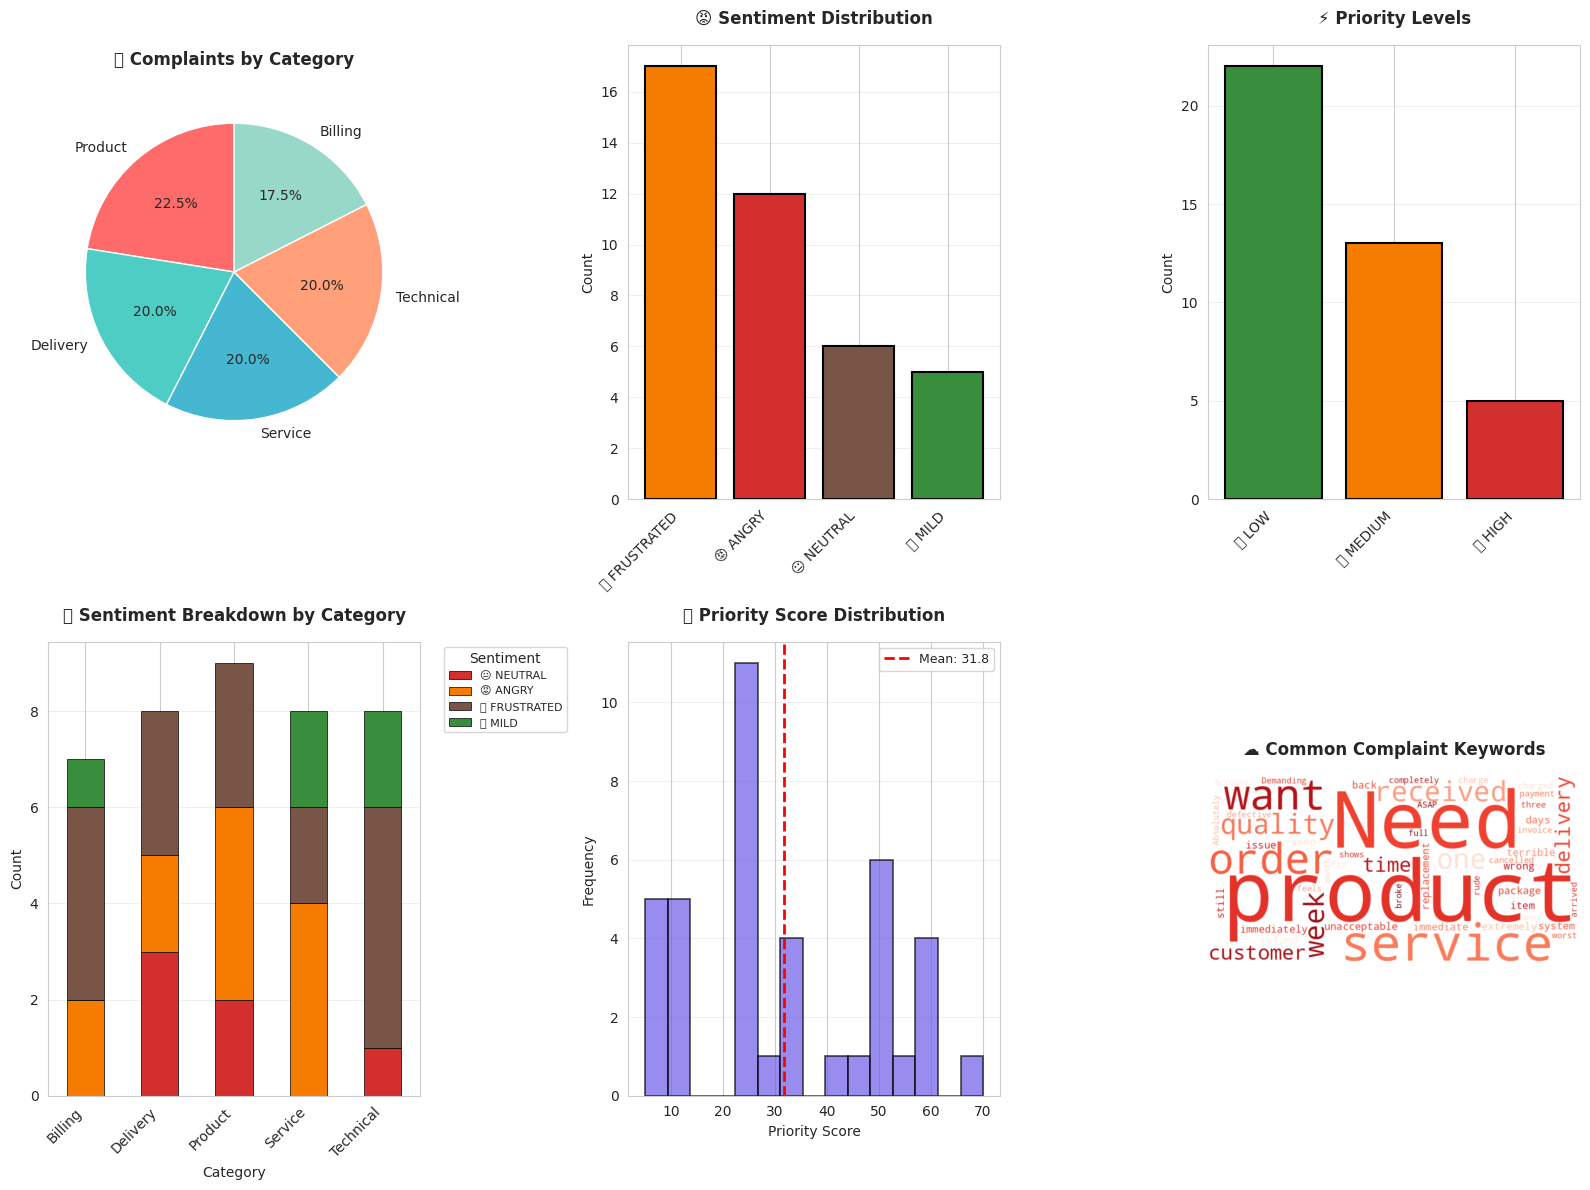


✅ Dashboard generated successfully!
📸 Saved as 'complaint_analysis_dashboard.png' for your presentation


In [10]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(16, 12))

# 1. Category Distribution
ax1 = plt.subplot(2, 3, 1)
category_counts = df['category'].value_counts()
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors_cat, textprops={'fontsize': 10})
ax1.set_title('📊 Complaints by Category', fontsize=12, fontweight='bold', pad=15)

# 2. Sentiment Distribution
ax2 = plt.subplot(2, 3, 2)
sentiment_counts = df['sentiment'].value_counts()
colors_sent = [sentiment_analyzer.get_sentiment_color(s) for s in sentiment_counts.index]
ax2.bar(range(len(sentiment_counts)), sentiment_counts.values, color=colors_sent, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(sentiment_counts)))
ax2.set_xticklabels(sentiment_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('😡 Sentiment Distribution', fontsize=12, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)

# 3. Priority Distribution
ax3 = plt.subplot(2, 3, 3)
priority_counts = df['priority'].value_counts()
colors_pri = [priority_scorer.get_priority_color(p) for p in priority_counts.index]
ax3.bar(range(len(priority_counts)), priority_counts.values, color=colors_pri, edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(len(priority_counts)))
ax3.set_xticklabels(priority_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('⚡ Priority Levels', fontsize=12, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3)

# 4. Sentiment by Category
ax4 = plt.subplot(2, 3, 4)
sentiment_category = pd.crosstab(df['category'], df['sentiment'])
sentiment_category.plot(kind='bar', stacked=True, ax=ax4, 
                        color=['#d32f2f', '#f57c00', '#795548', '#388e3c'],
                        edgecolor='black', linewidth=0.5)
ax4.set_xlabel('Category', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_title('📈 Sentiment Breakdown by Category', fontsize=12, fontweight='bold', pad=15)
ax4.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# 5. Priority Score Distribution
ax5 = plt.subplot(2, 3, 5)
ax5.hist(df['priority_score'], bins=15, color='#6C5CE7', edgecolor='black', linewidth=1.2, alpha=0.7)
ax5.axvline(df['priority_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["priority_score"].mean():.1f}')
ax5.set_xlabel('Priority Score', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.set_title('📊 Priority Score Distribution', fontsize=12, fontweight='bold', pad=15)
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)

# 6. Word Cloud
ax6 = plt.subplot(2, 3, 6)
all_complaints_text = ' '.join(df['complaint'].values)
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='Reds', max_words=50).generate(all_complaints_text)
ax6.imshow(wordcloud, interpolation='bilinear')
ax6.axis('off')
ax6.set_title('☁️ Common Complaint Keywords', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('complaint_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard generated successfully!")
print("📸 Saved as 'complaint_analysis_dashboard.png' for your presentation")

In [11]:
# Summary Statistics
print("="*100)
print("📊 COMPLAINT ANALYSIS SUMMARY")
print("="*100)

print(f"\n📈 Overall Statistics:")
print(f"  • Total Complaints Analyzed: {len(df)}")
print(f"  • Average Sentiment Score: {df['sentiment_score'].mean():.3f}")
print(f"  • Average Priority Score: {df['priority_score'].mean():.1f}/100")

print(f"\n🔴 High Priority Alerts:")
high_priority = df[df['priority'] == '🔴 HIGH']
print(f"  • {len(high_priority)} complaints require immediate attention")
print(f"  • Most common category: {high_priority['category'].mode().values[0] if len(high_priority) > 0 else 'N/A'}")

print(f"\n😡 Sentiment Insights:")
angry_complaints = df[df['sentiment'] == '😡 ANGRY']
print(f"  • {len(angry_complaints)} very angry customers ({len(angry_complaints)/len(df)*100:.1f}%)")
print(f"  • Most common anger trigger: {angry_complaints['category'].mode().values[0] if len(angry_complaints) > 0 else 'N/A'}")

print(f"\n📦 Category Insights:")
for category in df['category'].unique():
    cat_data = df[df['category'] == category]
    avg_sentiment = cat_data['sentiment_score'].mean()
    print(f"  • {classifier.get_category_icon(category)} {category}: {len(cat_data)} complaints (Avg sentiment: {avg_sentiment:.3f})")

print("\n" + "="*100)

📊 COMPLAINT ANALYSIS SUMMARY

📈 Overall Statistics:
  • Total Complaints Analyzed: 40
  • Average Sentiment Score: -0.362
  • Average Priority Score: 31.8/100

🔴 High Priority Alerts:
  • 5 complaints require immediate attention
  • Most common category: Product

😡 Sentiment Insights:
  • 12 very angry customers (30.0%)
  • Most common anger trigger: Product

📦 Category Insights:
  • 💰 Billing: 7 complaints (Avg sentiment: -0.408)
  • 📦 Product: 9 complaints (Avg sentiment: -0.486)
  • 👥 Service: 8 complaints (Avg sentiment: -0.370)
  • 🚚 Delivery: 8 complaints (Avg sentiment: -0.340)
  • 💻 Technical: 8 complaints (Avg sentiment: -0.197)



## 🎯 Step 10: Demonstration Examples

Test with various complaint scenarios.

In [12]:
# Test Cases for Presentation
test_complaints = [
    {
        "name": "Sarah Johnson",
        "complaint": "This is absolutely ridiculous! I was charged $500 for a service I never ordered. I want an immediate refund or I'm taking legal action!",
        "description": "Angry customer with billing fraud concern"
    },
    {
        "name": "Mike Chen",
        "complaint": "The delivery was supposed to arrive yesterday but it still hasn't come. Can you please check the tracking?",
        "description": "Calm customer with delivery inquiry"
    },
    {
        "name": "Emily Rodriguez",
        "complaint": "Your app keeps crashing when I try to make a payment. I've tried three times and it's really frustrating. I need this fixed urgently.",
        "description": "Frustrated customer with technical issue"
    }
]

print("="*100)
print("🧪 DEMONSTRATION: Testing Different Complaint Scenarios")
print("="*100 + "\n")

for i, test in enumerate(test_complaints, 1):
    print(f"\n{'='*100}")
    print(f"TEST CASE #{i}: {test['description']}")
    print(f"{'='*100}\n")
    analyze_new_complaint(test['complaint'], test['name'])
    print("\n" + "⏸"*50 + "\n")

🤖 CUSTOMER COMPLAINT ANALYSIS REPORT

📝 ORIGINAL COMPLAINT:
Your app keeps crashing when I try to make a payment. I've tried three times and it's really frustrating. I need this fixed urgently.

────────────────────────────────────────────────────────────────────────────────────────────────────

📊 ANALYSIS RESULTS:

  💻 CATEGORY: Technical (Confidence: 27.2%)
  😤 FRUSTRATED SENTIMENT (Score: -0.493)
  🟡 MEDIUM PRIORITY (Score: 35/100)

────────────────────────────────────────────────────────────────────────────────────────────────────

💡 RECOMMENDED ACTION:
  ⚡ Route to appropriate department
  ⚡ Respond within 24 hours

────────────────────────────────────────────────────────────────────────────────────────────────────

💬 SUGGESTED RESOLUTION TEMPLATE:

Dear Emily Rodriguez,

We apologize for the technical difficulties.
Our support team is working on a solution.
We'll contact you with troubleshooting steps within 24 hours.
Thank you for your patience.

Best regards,
Customer Support T